In [13]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sys
import joblib
import pandas as pd
from pathlib import Path
from sklearn.compose import ColumnTransformer

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.base import clone

sys.path.append(str(Path("..").resolve()))

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

RANDOM_STATE = 42
PROCESSED_DIR = Path("../data/interim")
MODEL_DIR = Path("../models")
REPORT_DIR = Path("../reports")

In [14]:
X_train_pre: pd.DataFrame = pd.read_csv(PROCESSED_DIR / "X_train_pre.csv", index_col=0)
X_val_pre: pd.DataFrame   = pd.read_csv(PROCESSED_DIR / "X_val_pre.csv",   index_col=0)
X_test_pre: pd.DataFrame  = pd.read_csv(PROCESSED_DIR / "X_test_pre.csv",  index_col=0)

y_train: pd.Series = pd.read_csv(PROCESSED_DIR / "y_train.csv", index_col=0).squeeze()
y_val: pd.Series   = pd.read_csv(PROCESSED_DIR / "y_val.csv",   index_col=0).squeeze()

feature_pipeline: Pipeline = joblib.load(MODEL_DIR / "feature_pipeline.joblib")
feature_transformer: ColumnTransformer = joblib.load(MODEL_DIR / "feature_transformer.joblib")

print(f"Successfully loaded data!")
print(f"Train: {X_train_pre.shape} | Val: {X_val_pre.shape} | Test: {X_test_pre.shape}")

Successfully loaded data!
Train: (112560, 35) | Val: (28140, 35) | Test: (93800, 35)


In [15]:
models: dict[str, object] = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        C=1.0,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=10,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        tree_method="hist",
        scale_pos_weight=4,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
}

In [16]:
def evaluate_model(
    name: str, model: object, X_val: pd.DataFrame, y_val: pd.Series) -> tuple[dict[str, object], np.ndarray]:
    """
    Generate predictions and compute all evaluation metrics for a model.

    Returns:
        tuple: (metrics_dict, y_pred)
        - metrics_dict: A dictionary containing the model name and metric scores.
        - y_pred: Predicted labels, returned for reuse to avoid calling predict() twice.
    """
    y_pred: np.ndarray  = model.predict(X_val)
    y_proba: np.ndarray = model.predict_proba(X_val)[:, 1]

    metrics: dict[str, object] = {
        "model":     name,
        "accuracy":  accuracy_score(y_val, y_pred),
        "precision": precision_score(y_val, y_pred, zero_division=0),
        "recall":    recall_score(y_val, y_pred, zero_division=0),
        "f1":        f1_score(y_val, y_pred, zero_division=0),
        "roc_auc":   roc_auc_score(y_val, y_proba),
    }
    return metrics, y_pred

In [17]:
results: list[dict] = []
fitted_models: dict[str, Pipeline] = {}
reports: dict[str, str] = {}

for name, classifier in models.items():
    print(f"Training: {name}...")

    full_model: Pipeline = Pipeline(steps=[
        ("feature_transformer", clone(feature_transformer)),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("classifier", classifier),
    ])

    full_model.fit(X_train_pre, y_train)
    fitted_models[name] = full_model

    metrics, y_pred = evaluate_model(name, full_model, X_val_pre, y_val)

    results.append(metrics)
    reports[name] = classification_report(
        y_val,
        y_pred,
        target_names=["Non-Depression (0)", "Depression (1)"]
    )

    print(f"{name}: F1={metrics['f1']:.4f} | ROC-AUC={metrics['roc_auc']:.4f}")

print("Training completely!")

Training: Logistic Regression...
Logistic Regression: F1=0.8024 | ROC-AUC=0.9731
Training: Decision Tree...
Decision Tree: F1=0.8014 | ROC-AUC=0.9616
Training: Random Forest...
Random Forest: F1=0.8227 | ROC-AUC=0.9716
Training: XGBoost...
XGBoost: F1=0.7903 | ROC-AUC=0.9734
Training completely!


In [18]:
results_df: pd.DataFrame = (
    pd.DataFrame(results)
    .sort_values(by=["f1", "roc_auc"], ascending=False)
    .reset_index(drop=True)
)

styled = results_df.style.format({
    "accuracy":  "{:.4f}",
    "precision": "{:.4f}",
    "recall":    "{:.4f}",
    "f1":        "{:.4f}",
    "roc_auc":   "{:.4f}",
}).highlight_max(
    subset=["accuracy", "precision", "recall", "f1", "roc_auc"],
    color="lightgreen",
)

display(styled)

best_name: str = results_df.loc[0, "model"]
print(f"\nBest model based on F1-Score: {best_name}")
print(f"\nClassification Report:\n{reports[best_name]}")

,model,accuracy,precision,recall,f1,roc_auc
0,Random Forest,0.9331,0.7933,0.8543,0.8227,0.9716
1,Logistic Regression,0.9176,0.7110,0.9206,0.8024,0.9731
2,Decision Tree,0.9226,0.7504,0.8598,0.8014,0.9616
3,XGBoost,0.9100,0.6850,0.9337,0.7903,0.9734



Best model based on F1-Score: Random Forest

Classification Report:
                    precision    recall  f1-score   support

Non-Depression (0)       0.97      0.95      0.96     23027
    Depression (1)       0.79      0.85      0.82      5113

          accuracy                           0.93     28140
         macro avg       0.88      0.90      0.89     28140
      weighted avg       0.94      0.93      0.93     28140



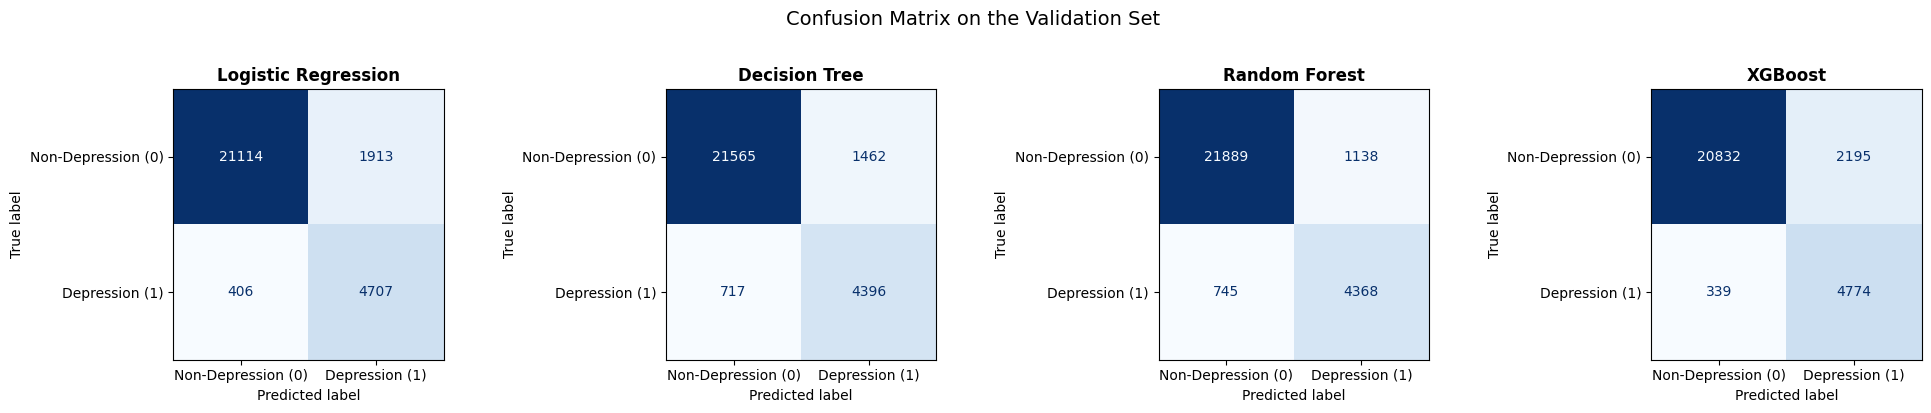

In [19]:
n_models: int = len(fitted_models)
fig, axes = plt.subplots(
    nrows=1, ncols=n_models,
    figsize=(5 * n_models, 4)
)

if n_models == 1:
    axes = [axes]

for ax, (name, model) in zip(axes, fitted_models.items()):
    y_pred: np.ndarray = model.predict(X_val_pre)
    cm: np.ndarray = confusion_matrix(y_val, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Non-Depression (0)", "Depression (1)"]
    )
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=12, fontweight="bold")

plt.suptitle("Confusion Matrix on the Validation Set", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(REPORT_DIR / "confusion_matrices.png", bbox_inches="tight", dpi=150)
plt.show()

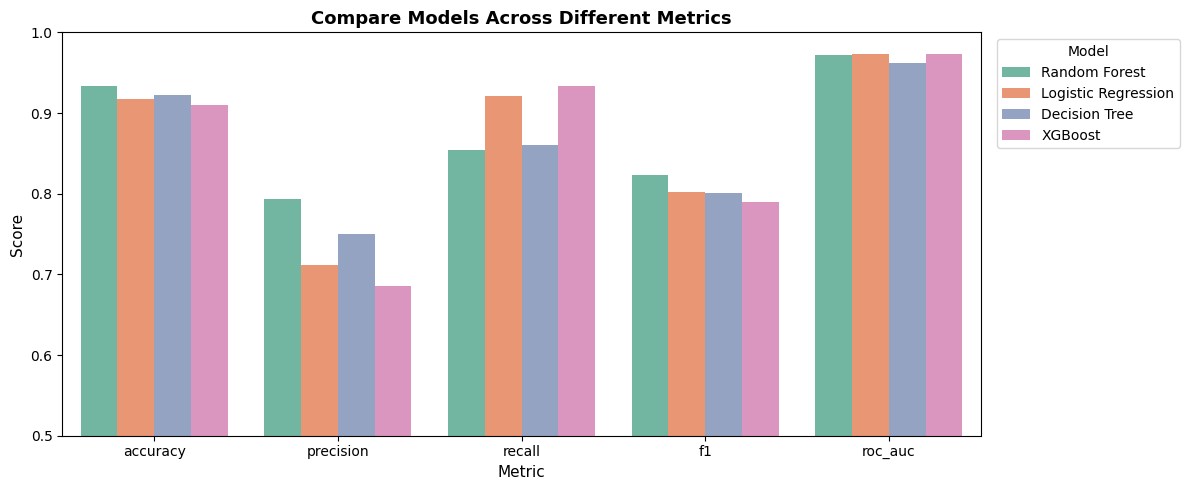

In [20]:
metrics_to_plot = ["accuracy", "precision", "recall", "f1", "roc_auc"]

plot_df: pd.DataFrame = results_df.melt(
    id_vars="model",
    value_vars=metrics_to_plot,
    var_name="metric",
    value_name="score",
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=plot_df, x="metric", y="score", hue="model", palette="Set2", ax=ax)

ax.set_ylim(0.5, 1.0)
ax.set_title("Compare Models Across Different Metrics", fontsize=13, fontweight="bold")
ax.set_xlabel("Metric", fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.legend(title="Model", bbox_to_anchor=(1.01, 1), loc="upper left")

plt.tight_layout()
plt.savefig(REPORT_DIR / "model_comparison.png", bbox_inches="tight", dpi=150)
plt.show()

In [22]:
import shap
import pandas as pd
import numpy as np

best_model = fitted_models[best_name]

# Lấy từng phần trong pipeline
fitted_transformer = best_model.named_steps["feature_transformer"]
classifier = best_model.named_steps["classifier"]

# Transform validation set
X_val_transformed = fitted_transformer.transform(X_val_pre)

# Lấy tên feature sau one-hot
feature_names = fitted_transformer.get_feature_names_out()

X_val_transformed_df = pd.DataFrame(
    X_val_transformed,
    columns=feature_names,
    index=X_val_pre.index
)

# Sample để chạy nhanh hơn
X_shap = X_val_transformed_df.sample(
    n=min(2000, len(X_val_transformed_df)),
    random_state=RANDOM_STATE
)

# SHAP explainer
explainer = shap.Explainer(classifier, X_shap)
shap_values = explainer(X_shap)

# Nếu binary classifier có output nhiều chiều, lấy class 1
values = shap_values.values
if values.ndim == 3:
    values = values[:, :, 1]

shap_importance = pd.DataFrame({
    "feature_encoded": X_shap.columns,
    "mean_abs_shap": np.abs(values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

display(shap_importance.head(30))

/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|===================| 3998/4000 [09:31<00:00]        

,feature_encoded,mean_abs_shap
0,num__Age,0.066107
6,num__Have you ever had suicidal thoughts ?,0.045560
27,num__Suicide_Pressure_Interaction,0.040231
8,num__Financial Stress,0.017798
26,num__Is_Young_Adult,0.017793
1,num__Academic Pressure,0.017539
23,num__Pressure_Satisfaction_Gap,0.017353
19,num__Total Pressure,0.017333
109,cat__Dietary Habits_Unhealthy,0.016575
5,num__Job Satisfaction,0.016282


In [21]:
MODEL_DIR.mkdir(exist_ok=True)

print("Saving models...")

for name, model in fitted_models.items():
    filename = f"model_{name.lower().replace(' ', '_')}.joblib"
    joblib.dump(model, MODEL_DIR / filename)
    print(f"Saved: {filename}")

print(f"\nAll models are saved into folder: {MODEL_DIR.resolve()}")

Saving models...
Saved: model_logistic_regression.joblib
Saved: model_decision_tree.joblib
Saved: model_random_forest.joblib
Saved: model_xgboost.joblib

All models are saved into folder: /Users/hongphuc/CS114-Depression-Prediction/ml/models
